In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"athiqurrahman00","key":"d860d50a14eaf87aeb0b514b89d6d1ec"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:22<00:00, 96.4MB/s]



In [5]:
!ls -lh

total 2.1G
-rw-r--r-- 1 root root 2.1G Nov 20  2020 eurosat-dataset.zip
-rw-r--r-- 1 root root   71 Jun  4 03:37 kaggle.json
drwxr-xr-x 1 root root 4.0K May 26 13:31 sample_data


Extract the Dataset

In [6]:
import zipfile

with zipfile.ZipFile('/content/eurosat-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/eurosat_dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


Verifying Extract

In [7]:
import os

print(os.listdir('/content/eurosat_dataset'))

['EuroSAT', 'EuroSATallBands']


In [8]:
import os

dataset_path = "/content/eurosat_dataset/EuroSAT"

print(os.listdir(dataset_path))

['HerbaceousVegetation', 'Pasture', 'River', 'label_map.json', 'Industrial', 'Highway', 'test.csv', 'PermanentCrop', 'AnnualCrop', 'validation.csv', 'train.csv', 'SeaLake', 'Forest', 'Residential']


Dataset Loading and Initial Exploration

In [9]:
import pandas as pd

base_path = "/content/eurosat_dataset/EuroSAT"

train_df = pd.read_csv(f"{base_path}/train.csv")
val_df = pd.read_csv(f"{base_path}/validation.csv")
test_df = pd.read_csv(f"{base_path}/test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (18900, 4)
Validation: (5400, 4)
Test: (2700, 4)


,Unnamed: 0,Filename,Label,ClassName
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
3,2223,Industrial/Industrial_453.jpg,4,Industrial
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation


Exploratory Data Analysis (EDA)

In [10]:
print(train_df["ClassName"].value_counts())

ClassName
AnnualCrop              2100
HerbaceousVegetation    2100
SeaLake                 2100
Forest                  2100
Residential             2100
PermanentCrop           1750
Industrial              1750
Highway                 1750
River                   1750
Pasture                 1400
Name: count, dtype: int64


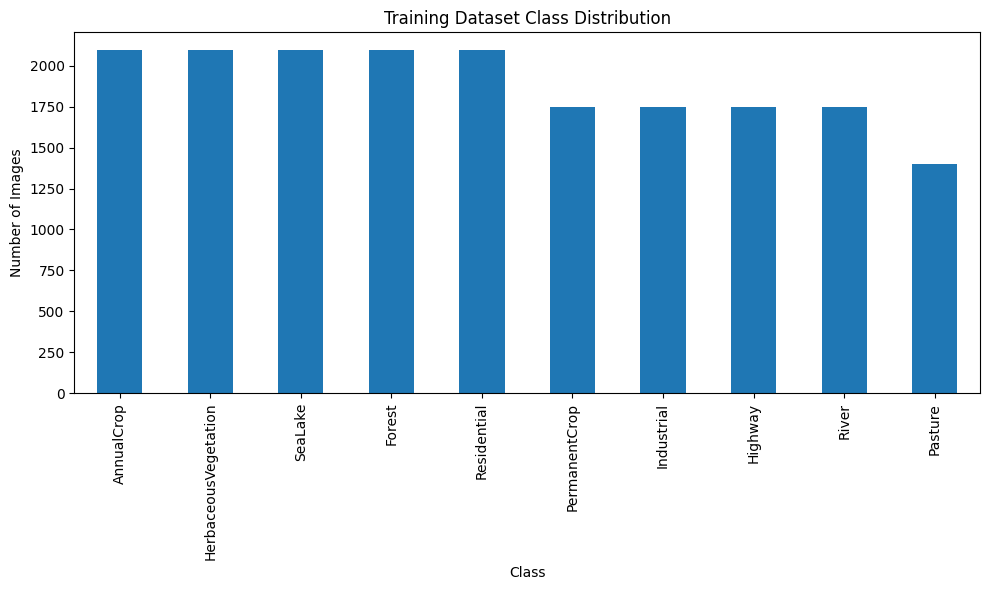

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

train_df["ClassName"].value_counts().plot(kind='bar')

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.savefig("class_distribution.png")

plt.show()

In [12]:
train_df["ClassName"].value_counts()

,count
ClassName,
AnnualCrop,2100
HerbaceousVegetation,2100
SeaLake,2100
Forest,2100
Residential,2100
PermanentCrop,1750
Industrial,1750
Highway,1750
River,1750


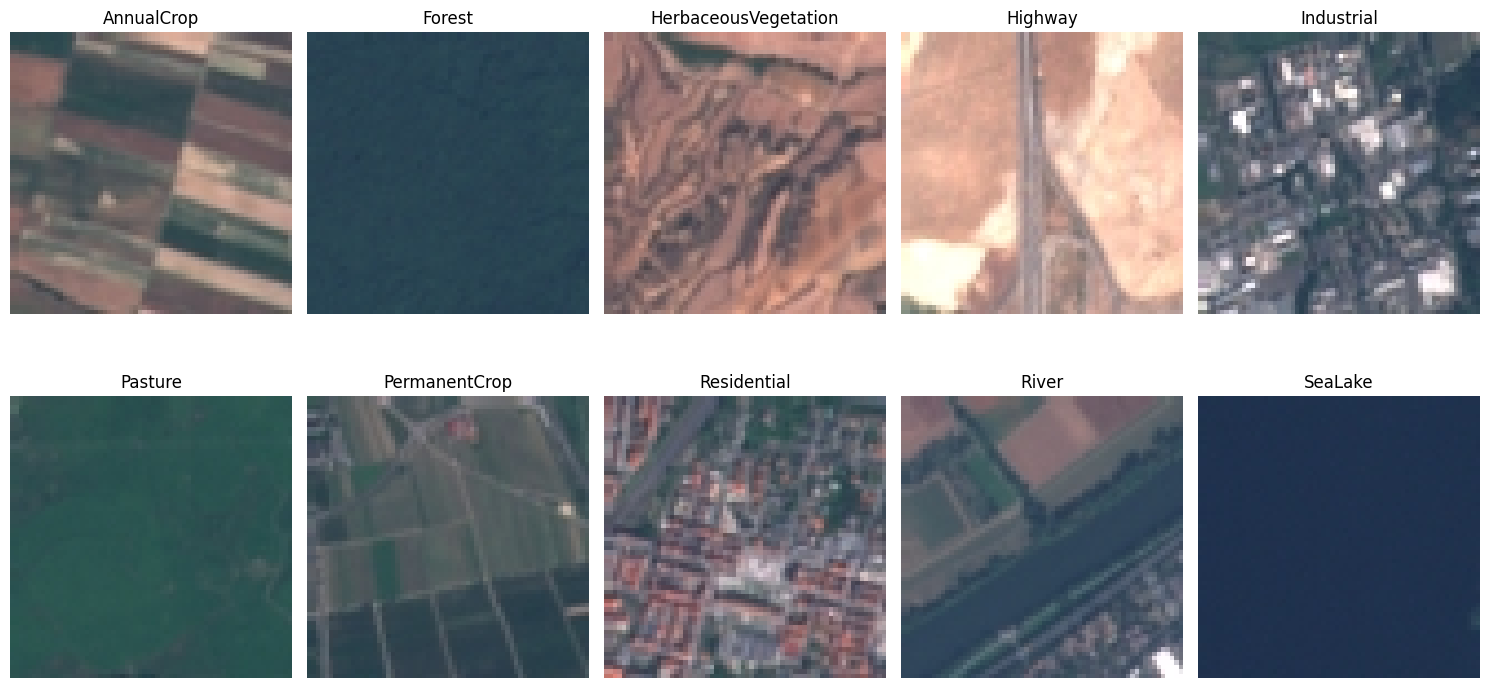

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_path = "/content/eurosat_dataset/EuroSAT"

classes = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(base_path, cls))[0]

    img_path = os.path.join(base_path, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_images.png")

plt.show()

Data Preprocessing and Augmentation

In [14]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [15]:
base_path = "/content/eurosat_dataset/EuroSAT"

train_df["filepath"] = train_df["Filename"].apply(
    lambda x: f"{base_path}/{x}"
)

val_df["filepath"] = val_df["Filename"].apply(
    lambda x: f"{base_path}/{x}"
)

test_df["filepath"] = test_df["Filename"].apply(
    lambda x: f"{base_path}/{x}"
)

train_df.head()

,Unnamed: 0,Filename,Label,ClassName,filepath
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop,/content/eurosat_dataset/EuroSAT/AnnualCrop/An...
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation,/content/eurosat_dataset/EuroSAT/HerbaceousVeg...
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop,/content/eurosat_dataset/EuroSAT/PermanentCrop...
3,2223,Industrial/Industrial_453.jpg,4,Industrial,/content/eurosat_dataset/EuroSAT/Industrial/In...
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation,/content/eurosat_dataset/EuroSAT/HerbaceousVeg...


Image Generators

In [16]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

Data Loaders

In [17]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="ClassName",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="ClassName",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="ClassName",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 18900 validated image filenames belonging to 10 classes.
Found 5400 validated image filenames belonging to 10 classes.
Found 2700 validated image filenames belonging to 10 classes.


In [18]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 10)


 Custom CNN Model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')

])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,270,346 (73.51 MB)

 Trainable params: 19,269,386 (73.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [20]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [22]:
train_generator

In [23]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 259s 417ms/step - accuracy: 0.4983 - loss: 8.7544 - val_accuracy: 0.5748 - val_loss: 1.2058 - learning_rate: 0.0010
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 235s 397ms/step - accuracy: 0.5918 - loss: 1.2291 - val_accuracy: 0.4748 - val_loss: 2.6079 - learning_rate: 0.0010
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 234s 396ms/step - accuracy: 0.6152 - loss: 1.1492 - val_accuracy: 0.4915 - val_loss: 3.5075 - learning_rate: 0.0010
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 233s 394ms/step - accuracy: 0.6214 - loss: 1.1515 - val_accuracy: 0.6552 - val_loss: 0.9935 - learning_rate: 0.0010
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 238s 403ms/step - accuracy: 0.6243 - loss: 1.1150 - val_accuracy: 0.4117 - val_loss: 2.6588 - learning_rate: 0.0010
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 244s 412ms/step - accuracy: 0.6537 - loss: 1.0530 - val_accuracy: 0.7026 - val_loss: 0.8918 - learning_rate: 0.0010
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 235s 397ms/step - accura

CNN Model Evaluation

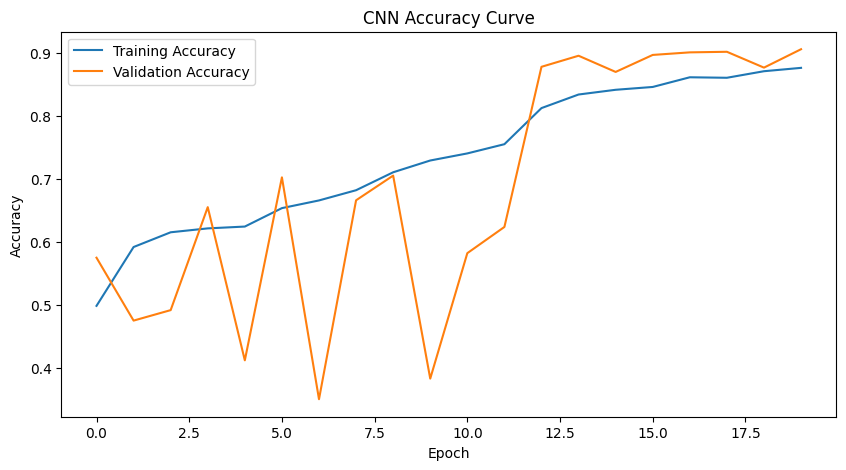

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_cnn.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_cnn.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("cnn_accuracy_curve.png")

plt.show()

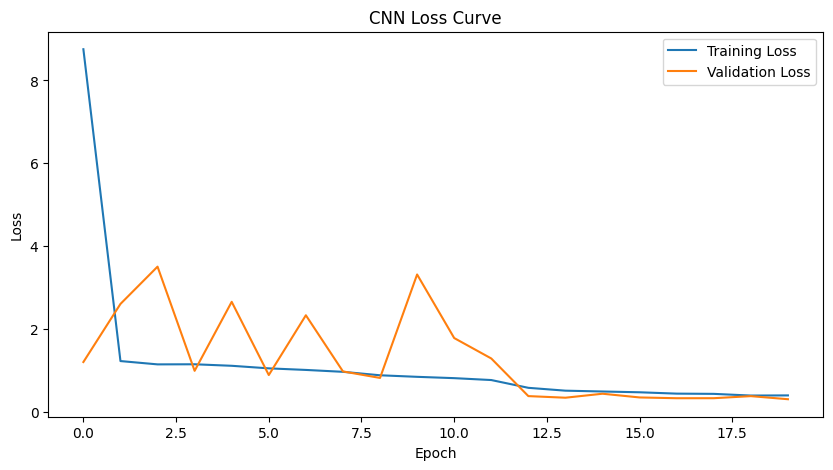

In [25]:
plt.figure(figsize=(10,5))

plt.plot(history_cnn.history['loss'],
         label='Training Loss')

plt.plot(history_cnn.history['val_loss'],
         label='Validation Loss')

plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig("cnn_loss_curve.png")

plt.show()

Confusion Matrix and Classification Report

In [26]:
cnn_predictions = cnn_model.predict(test_generator)

85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step


In [27]:
import numpy as np

y_pred = np.argmax(cnn_predictions, axis=1)

y_true = test_generator.classes

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

                      precision    recall  f1-score   support

          AnnualCrop       0.88      0.93      0.90       300
              Forest       0.95      1.00      0.97       300
HerbaceousVegetation       0.92      0.76      0.83       300
             Highway       0.88      0.82      0.85       250
          Industrial       0.96      0.90      0.93       250
             Pasture       0.89      0.93      0.91       200
       PermanentCrop       0.70      0.95      0.81       250
         Residential       0.98      0.99      0.99       300
               River       0.96      0.78      0.86       250
             SeaLake       0.99      0.98      0.99       300

            accuracy                           0.91      2700
           macro avg       0.91      0.90      0.90      2700
        weighted avg       0.91      0.91      0.91      2700



MobileNetV2 Model

In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [30]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [31]:
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [32]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 275s 434ms/step - accuracy: 0.7862 - loss: 0.6228 - val_accuracy: 0.8393 - val_loss: 0.4714 - learning_rate: 0.0010
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 227s 383ms/step - accuracy: 0.8442 - loss: 0.4599 - val_accuracy: 0.8420 - val_loss: 0.4662 - learning_rate: 0.0010
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 230s 389ms/step - accuracy: 0.8559 - loss: 0.4178 - val_accuracy: 0.8706 - val_loss: 0.3769 - learning_rate: 0.0010
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 227s 385ms/step - accuracy: 0.8781 - loss: 0.3561 - val_accuracy: 0.8689 - val_loss: 0.3748 - learning_rate: 2.0000e-04
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 226s 383ms/step - accuracy: 0.8881 - loss: 0.3327 - val_accuracy: 0.8811 - val_loss: 0.3444 - learning_rate: 2.0000e-04


Transfer Learning Evaluation

In [35]:
print("Final Training Accuracy:",
      history_mobilenet.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history_mobilenet.history['val_accuracy'][-1])

Final Training Accuracy: 0.8881481289863586
Final Validation Accuracy: 0.8811110854148865


In [36]:
mobilenet_predictions = mobilenet_model.predict(
    test_generator
)

import numpy as np

y_pred_mobile = np.argmax(
    mobilenet_predictions,
    axis=1
)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_mobile,
        target_names=list(
            test_generator.class_indices.keys()
        )
    )
)

85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step
                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.90      0.90       300
              Forest       0.92      0.93      0.93       300
HerbaceousVegetation       0.83      0.76      0.79       300
             Highway       0.82      0.64      0.72       250
          Industrial       0.74      0.98      0.84       250
             Pasture       0.85      0.74      0.79       200
       PermanentCrop       0.68      0.84      0.75       250
         Residential       0.96      0.94      0.95       300
               River       0.83      0.74      0.79       250
             SeaLake       0.99      0.98      0.99       300

            accuracy                           0.85      2700
           macro avg       0.85      0.85      0.84      2700
        weighted avg       0.86      0.85      0.85      2700



ResNet50 Transfer Learning

In [37]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [38]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_base.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
resnet_model = Sequential([
    resnet_base,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [40]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [42]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 275s 444ms/step - accuracy: 0.1447 - loss: 2.2390 - val_accuracy: 0.2267 - val_loss: 2.0817 - learning_rate: 0.0010
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 252s 427ms/step - accuracy: 0.1953 - loss: 2.0883 - val_accuracy: 0.2769 - val_loss: 1.9623 - learning_rate: 0.0010
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 247s 418ms/step - accuracy: 0.2223 - loss: 2.0464 - val_accuracy: 0.2774 - val_loss: 1.9154 - learning_rate: 0.0010
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 248s 419ms/step - accuracy: 0.2325 - loss: 2.0150 - val_accuracy: 0.3109 - val_loss: 1.9030 - learning_rate: 2.0000e-04
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 248s 419ms/step - accuracy: 0.2340 - loss: 2.0082 - val_accuracy: 0.2878 - val_loss: 1.8731 - learning_rate: 2.0000e-04


In [43]:
resnet_predictions = resnet_model.predict(
    test_generator
)

import numpy as np

y_pred_resnet = np.argmax(
    resnet_predictions,
    axis=1
)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_resnet,
        target_names=list(
            test_generator.class_indices.keys()
        )
    )
)

85/85 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step
                      precision    recall  f1-score   support

          AnnualCrop       0.00      0.00      0.00       300
              Forest       0.16      1.00      0.28       300
HerbaceousVegetation       0.10      0.08      0.09       300
             Highway       0.00      0.00      0.00       250
          Industrial       0.63      0.89      0.74       250
             Pasture       0.00      0.00      0.00       200
       PermanentCrop       0.00      0.00      0.00       250
         Residential       0.32      0.24      0.27       300
               River       0.00      0.00      0.00       250
             SeaLake       0.00      0.00      0.00       300

            accuracy                           0.23      2700
           macro avg       0.12      0.22      0.14      2700
        weighted avg       0.12      0.23      0.14      2700



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model Comparison

In [44]:
comparison_df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],
    "Accuracy": [
        0.91,
        0.85,
        0.23
    ]
})

comparison_df

,Model,Accuracy
0,Custom CNN,0.91
1,MobileNetV2,0.85
2,ResNet50,0.23


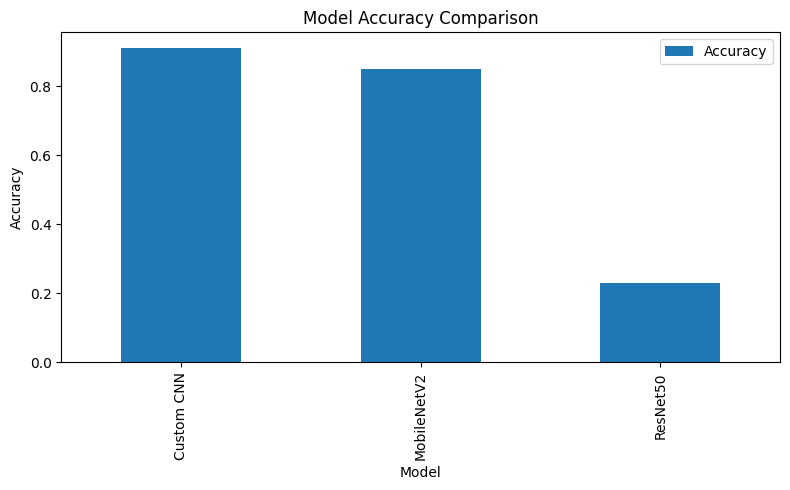

In [45]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.tight_layout()

plt.savefig("model_comparison.png")

plt.show()

Fine-Tune ResNet50

In [46]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

In [47]:
from tensorflow.keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
from tensorflow.keras.callbacks import EarlyStopping

fine_tune_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [49]:
history_resnet_ft = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[fine_tune_stop]
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 285s 448ms/step - accuracy: 0.3256 - loss: 2.0073 - val_accuracy: 0.5111 - val_loss: 1.4562
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 252s 426ms/step - accuracy: 0.4872 - loss: 1.4386 - val_accuracy: 0.4724 - val_loss: 1.4004
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 261s 441ms/step - accuracy: 0.5560 - loss: 1.2609 - val_accuracy: 0.3972 - val_loss: 1.7645
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 259s 438ms/step - accuracy: 0.5959 - loss: 1.1500 - val_accuracy: 0.6376 - val_loss: 1.0168
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 257s 434ms/step - accuracy: 0.6217 - loss: 1.0786 - val_accuracy: 0.5054 - val_loss: 1.4165


In [50]:
resnet_ft_predictions = resnet_model.predict(test_generator)

85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 146ms/step


In [51]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_resnet_ft = np.argmax(
    resnet_ft_predictions,
    axis=1
)

print(
    classification_report(
        y_true,
        y_pred_resnet_ft,
        target_names=list(
            test_generator.class_indices.keys()
        )
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.83      0.76      0.79       300
              Forest       0.76      0.91      0.83       300
HerbaceousVegetation       0.66      0.16      0.26       300
             Highway       0.32      0.53      0.40       250
          Industrial       0.84      0.86      0.85       250
             Pasture       0.11      0.01      0.01       200
       PermanentCrop       0.60      0.44      0.50       250
         Residential       0.79      0.98      0.87       300
               River       0.33      0.56      0.41       250
             SeaLake       0.85      0.94      0.89       300

            accuracy                           0.64      2700
           macro avg       0.61      0.61      0.58      2700
        weighted avg       0.63      0.64      0.61      2700



Grad-CAM Visualization

In [52]:
for layer in cnn_model.layers:
    print(layer.name)

conv2d
batch_normalization
max_pooling2d
conv2d_1
batch_normalization_1
max_pooling2d_1
conv2d_2
batch_normalization_2
max_pooling2d_2
conv2d_3
batch_normalization_3
max_pooling2d_3
flatten
dense
dropout
dense_1


In [53]:
import random

sample_image = test_df.iloc[0]["filepath"]

print(sample_image)

/content/eurosat_dataset/EuroSAT/AnnualCrop/AnnualCrop_1275.jpg


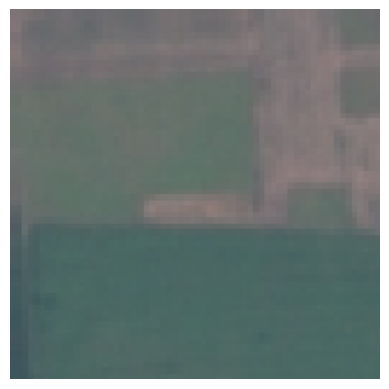

In [54]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = sample_image

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

plt.imshow(img)
plt.axis("off")
plt.show()

In [58]:
print(cnn_model.inputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]


In [59]:
print(cnn_model.outputs)

[<KerasTensor shape=(None, 10), dtype=float32, sparse=False, ragged=False, name=keras_tensor_16>]


In [60]:
import tensorflow as tf

grad_model = tf.keras.models.Model(
    inputs=cnn_model.inputs,
    outputs=[
        cnn_model.get_layer("conv2d_3").output,
        cnn_model.outputs[0]
    ]
)

print("Grad-CAM model created successfully")

Grad-CAM model created successfully


In [61]:
import tensorflow as tf

grad_model = tf.keras.models.Model(
    inputs=cnn_model.inputs,
    outputs=[
        cnn_model.get_layer("conv2d_3").output,
        cnn_model.outputs[0]
    ]
)

print("Grad-CAM model created successfully")

Grad-CAM model created successfully


In [64]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    predicted_class = tf.argmax(predictions[0])

    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0)

heatmap = heatmap / np.max(heatmap)

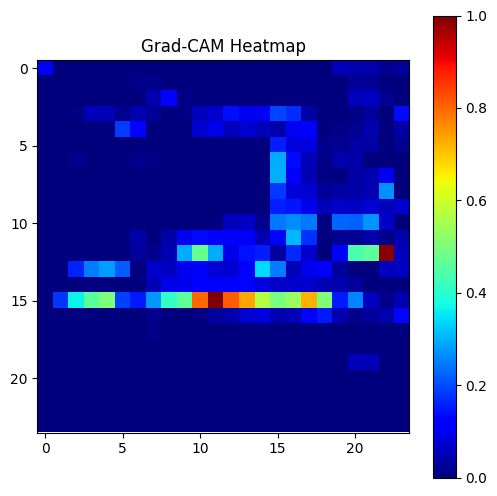

In [65]:
plt.figure(figsize=(6,6))

plt.imshow(heatmap, cmap="jet")

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.show()

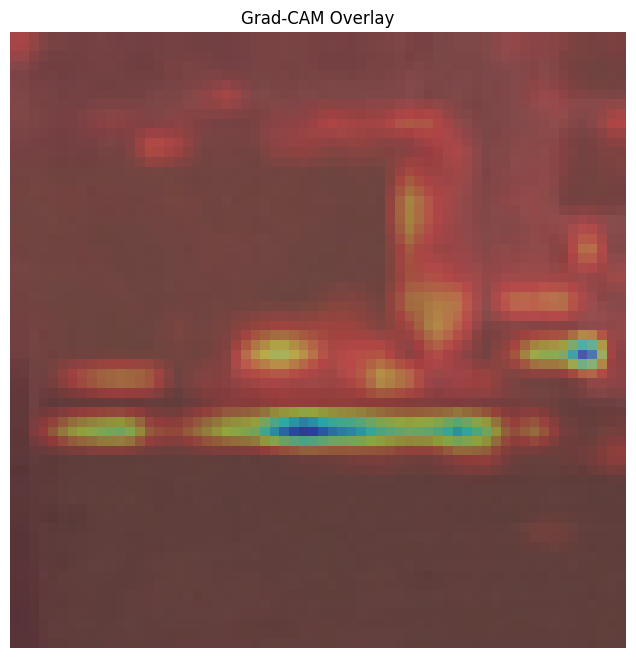

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_original = cv2.imread(img_path)

img_original = cv2.cvtColor(
    img_original,
    cv2.COLOR_BGR2RGB
)

heatmap_resized = cv2.resize(
    heatmap,
    (
        img_original.shape[1],
        img_original.shape[0]
    )
)

heatmap_resized = np.uint8(
    255 * heatmap_resized
)

heatmap_colored = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    img_original,
    0.6,
    heatmap_colored,
    0.4,
    0
)

plt.figure(figsize=(8,8))

plt.imshow(superimposed_img)

plt.axis("off")

plt.title("Grad-CAM Overlay")

plt.savefig("gradcam_overlay.png")

plt.show()

Conclusion

In [67]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50 (Frozen)",
        "ResNet50 (Fine-Tuned)"
    ],
    "Accuracy (%)": [
        91,
        85,
        23,
        64
    ]
})

comparison_df

,Model,Accuracy (%)
0,Custom CNN,91
1,MobileNetV2,85
2,ResNet50 (Frozen),23
3,ResNet50 (Fine-Tuned),64


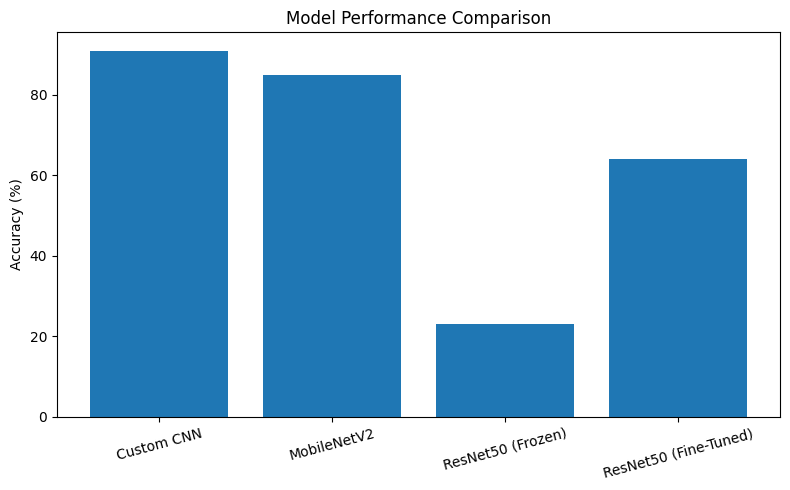

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("model_comparison.png")

plt.show()

CNN Confusion Matrix

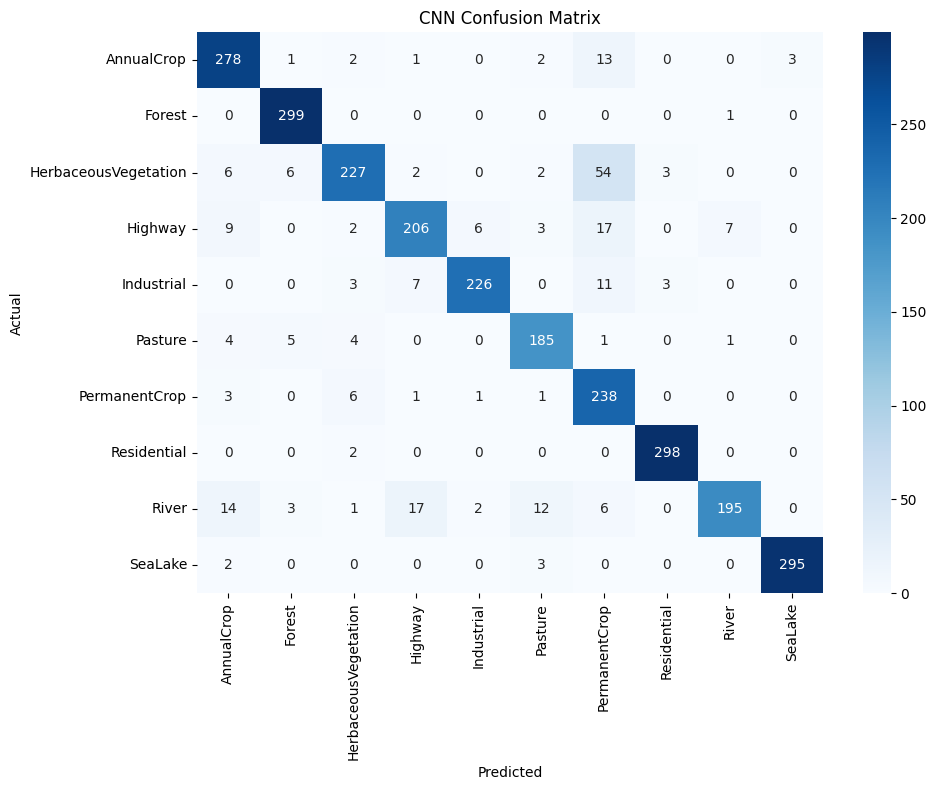

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("cnn_confusion_matrix.png")

plt.show()

In [71]:
import zipfile
import os

with zipfile.ZipFile('project_figures.zip', 'w') as zipf:
    for file in os.listdir():
        if file.endswith('.png'):
            zipf.write(file)

print("ZIP file created successfully")

ZIP file created successfully
